# High Performance Data Processing: Project 1 Evaluation Charts
This notebook reads the benchmark results generated by our pipeline and creates comparison tables and charts.

**Metrics Analyzed:**
1. Total Processing Time (seconds)
2. Peak Memory Consumption (MB)
3. Throughput (records/sec)
4. Average CPU Utilization (%)

**Framework Color Coding:**
* **Pandas:** Blue
* **Dask:** Orange
* **PySpark:** Green

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Suppress visual warnings
import warnings
warnings.filterwarnings('ignore')

# File paths from our benchmark execution
file_before = "performance_before.csv"
file_after = "performance_after.csv"

# Check if files exist before running to avoid errors
if not os.path.exists(file_before) or not os.path.exists(file_after):
    raise FileNotFoundError(
        "Could not find the benchmark output files. "
        "Please run your benchmark pipeline script first to generate "
        "'performance_before.csv' and 'performance_after.csv'."
    )

# Load the data
df_before = pd.read_csv(file_before)
df_after = pd.read_csv(file_after)

print("Successfully loaded both performance metric files!")

Successfully loaded both performance metric files!


---
## 1. Evaluation Tables
We filter out the individual run entries to focus purely on the calculated **Average** rows for a clean, side-by-side comparison of the frameworks.

In [2]:
# Filter out only the 'Average' summary rows
avg_before = df_before[df_before['Run'] == 'Average'].copy()
avg_after = df_after[df_after['Run'] == 'Average'].copy()

# Remove columns that clutter the table output
columns_to_drop = ['Run', 'Version']
table_before = avg_before.drop(columns=columns_to_drop).reset_index(drop=True)
table_after = avg_after.drop(columns=columns_to_drop).reset_index(drop=True)

print("=== AVERAGE PERFORMANCE: BASELINE PIPELINE (BEFORE OPTIMIZATION) ===")
display(table_before)

print("\n=== AVERAGE PERFORMANCE: OPTIMIZED PIPELINE (AFTER OPTIMIZATION) ===")
display(table_after)

=== AVERAGE PERFORMANCE: BASELINE PIPELINE (BEFORE OPTIMIZATION) ===


,Framework,Total_Time_sec,Avg_CPU_percent,Peak_Memory_MB,Throughput_rec_per_sec
0,Pandas,2.2281,93.91,1379.19,85015.13
1,Dask,2.2576,112.87,1137.43,85740.10
2,PySpark,1.6110,9.76,1076.33,249098.09



=== AVERAGE PERFORMANCE: OPTIMIZED PIPELINE (AFTER OPTIMIZATION) ===


,Framework,Total_Time_sec,Avg_CPU_percent,Peak_Memory_MB,Throughput_rec_per_sec
0,Pandas,1.5428,92.06,1332.43,122796.16
1,Dask,1.4505,116.79,1415.54,130787.18
2,PySpark,0.3497,7.45,1221.14,541946.42


---
## 2. Evaluation Charts
We combine the data to plot comparison bars. Each framework uses a highly distinct, strict color identifier:
* **Pandas** = Blue (`#1f77b4`)
* **Dask** = Orange (`#ff7f0e`)
* **PySpark** = Green (`#2ca02c`)

Charts successfully generated and saved as 'framework_comparison_charts.png'!


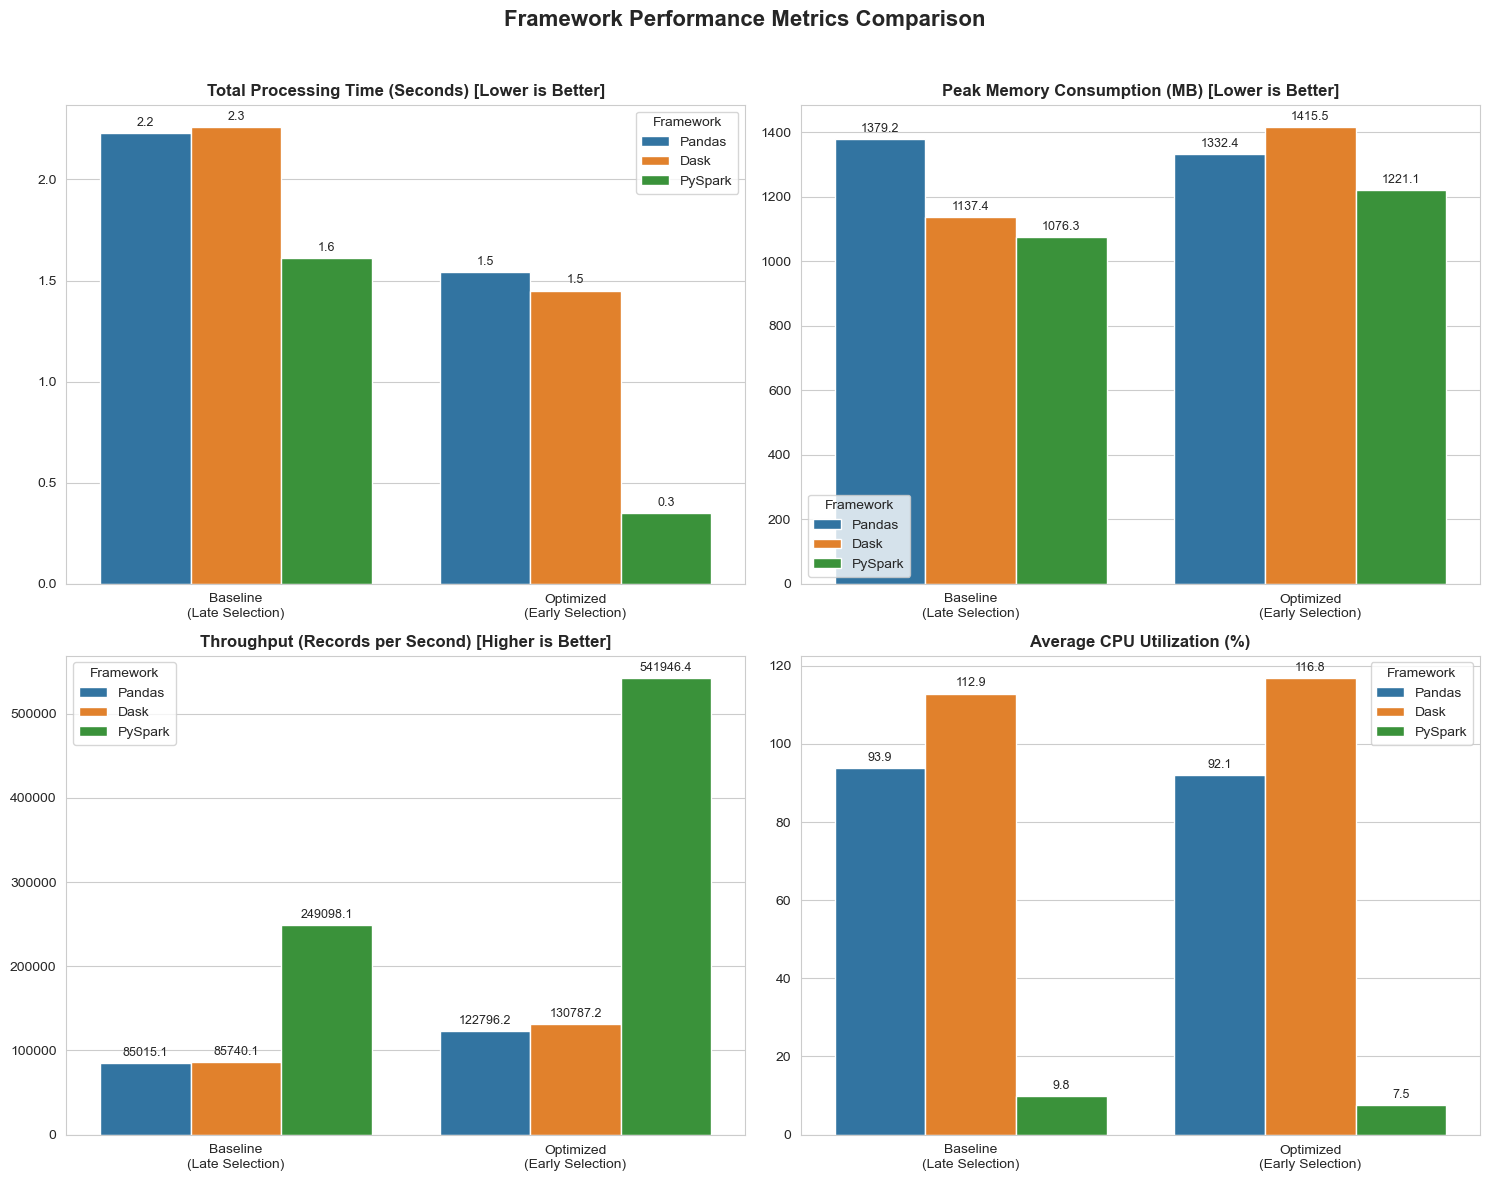

In [3]:
# Label the states so they display nicely on the X-axis
avg_before['Pipeline State'] = 'Baseline\n(Late Selection)'
avg_after['Pipeline State'] = 'Optimized\n(Early Selection)'

# Combine both into a single DataFrame for Seaborn plotting
plot_df = pd.concat([avg_before, avg_after])

# Configure the visual style and strict distinct color palette
sns.set_style("whitegrid")
framework_colors = {
    'Pandas': '#1f77b4',  # Distinct Blue
    'Dask': '#ff7f0e',    # Distinct Orange
    'PySpark': '#2ca02c'  # Distinct Green
}

# Create a 2x2 plotting grid for our 4 metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Framework Performance Metrics Comparison', fontsize=16, fontweight='bold')

# Structure: (Column Name, Chart Title Title, Axis Location)
metrics_to_plot = [
    ('Total_Time_sec', 'Total Processing Time (Seconds) [Lower is Better]', axes[0, 0]),
    ('Peak_Memory_MB', 'Peak Memory Consumption (MB) [Lower is Better]', axes[0, 1]),
    ('Throughput_rec_per_sec', 'Throughput (Records per Second) [Higher is Better]', axes[1, 0]),
    ('Avg_CPU_percent', 'Average CPU Utilization (%)', axes[1, 1])
]

# Loop through and generate each chart dynamically
for col_name, title, ax in metrics_to_plot:
    sns.barplot(
        data=plot_df, 
        x='Pipeline State', 
        y=col_name, 
        hue='Framework', 
        palette=framework_colors, 
        ax=ax
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Add numerical value tags on top of each bar for presentation clarity
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

# Adjust the layout elements so nothing overlaps or cuts off
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save the visualization figure locally as an image for reports
plt.savefig('framework_comparison_charts.png', dpi=300)
print("Charts successfully generated and saved as 'framework_comparison_charts.png'!")

# Display the charts here in the notebook
plt.show()